In [11]:
import sys
import os
import pandas as pd
import numpy as np
from pycox.models.cox import CoxPH
from pycox.evaluation import EvalSurv
import matplotlib.pyplot as plt
import shap
import scipy.integrate
scipy.integrate.simps = scipy.integrate.simpson



from itertools import product
import torch

sys.path.append(os.path.abspath("../../"))
from src.dataset.generate_dataset import TorchPreprocessing
from src.utils.kapplan_meir import k_m_cox
from src.dataset.DataSet import SurvivalDataSet
from src.utils.Preprocessing import Preprocessor
from src.utils.ConvertTextToCsv import TextToCsv
from src.dataset.split_data import split_dataset_by_ids
from src.utils.set_seed import set_seed
from src.utils.cox_models import *
from sklearn.utils import resample


import numpy as np
import torch
import torchtuples as tt

%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
set_seed(42)

In [13]:
pp = Preprocessor()

In [14]:
df_clinical_data = pd.read_csv("../../data/raw/brca_tcga_pub2015_clinical_data.tsv", sep='\t')
df_clinical_data = pp.clean_columns_dataset(df_clinical_data)
list_df = pp.total_type_len_type_cancer(df_clinical_data)
df_clinical_data["Tumor-Cancer"] = list_df
df_clinical_data["Tumor-Cancer"].unique()

df_mRNA_raw_data = TextToCsv("../../data/raw/data_mrna_seq_v2_rsem.txt")


Luminal A: 330 - Total(%): 0.40
Luminal B: 81 - Total(%):0.10
HER2-enriched: 23 - Total(%):0.03
TNBC: 85 - Total(%)0.10 
UNK: 299 - Total(%) 0.37
Shape of the CSV: (20440, 819)


In [15]:
df_merged = TorchPreprocessing(df_mRNA_raw_data,df_clinical_data, 23360).get_comparation_df()
 
comparation_df = df_merged.loc[
    df_merged["Tumor-Cancer"].isin(["Luminal A", "Luminal B", "TNBC", "HER2-enriched"]),
]

comparation_df["Tumor-Cancer"].unique()

print(f"Samples: {comparation_df.shape[0]}, Genes: {comparation_df.shape[1]}")

Genes before Treshold: 20434
count    20434.000000
mean        73.977831
std        155.539160
min          0.000000
25%          0.000000
50%          0.000000
75%         21.000000
max        519.000000
dtype: float64
Threshold (>80% zeros): 415 samples
After the treshold: 18533
Samples: 519, Genes: 18534


In [16]:

import json

with open("splits.json") as f:
    _split = json.load(f)
trainval_ids = set(_split["train_ids"]) | set(_split["val_ids"])

top_genes_limma = pd.read_csv("elasticnet_candidates.csv")["gene"].tolist()
print(f"Loaded {len(top_genes_limma)} genes from train-only limma panel (test patients excluded)")


Loaded 1000 genes from train-only limma panel (test patients excluded)


In [17]:
N_GENES = len(top_genes_limma)
print(f"N_GENES = {N_GENES} (loaded from elasticnet_candidates.csv, train-only limma)")


N_GENES = 1000 (loaded from elasticnet_candidates.csv, train-only limma)


In [18]:
torch_preprocessing = TorchPreprocessing(df_mRNA_raw_data, df_clinical_data, 23360)
torch_preprocessing.genes_expression = top_genes_limma
genes_expression = top_genes_limma
X_scaled, durations, events, scaler, sample_ids = torch_preprocessing.get_data_set(60, return_ids=True)


Genes before Treshold: 1003
count    1003.000000
mean        0.546361
std         2.151125
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        24.000000
dtype: float64
Threshold (>80% zeros): 415 samples
After the treshold: 1003


In [19]:
surival_data_set  = SurvivalDataSet(X_scaled, durations, events)



In [20]:
type(surival_data_set)

src.dataset.DataSet.SurvivalDataSet

In [21]:
import json
from src.dataset.split_data import split_dataset_by_ids

# Load the canonical split created by limma.ipynb so the NN uses the SAME patients.
split = json.load(open("splits.json"))
set_seed(42)
(train_X, train_durations, train_events), \
(val_X, val_durations, val_events), \
(test_X, test_durations, test_events) = split_dataset_by_ids(
    surival_data_set, sample_ids,
    split["train_ids"], split["val_ids"], split["test_ids"]
)
print(f"Train: {train_X.shape[0]}, Val: {val_X.shape[0]}, Test: {test_X.shape[0]}")
print(f"Train: {type(train_X)}, Val: {type(val_X)}, Test: {type(test_X)}")

Train: 331, Val: 84, Test: 104
Train: <class 'torch.Tensor'>, Val: <class 'torch.Tensor'>, Test: <class 'torch.Tensor'>


In [22]:
in_features = train_X.shape[1]
train_X_np = train_X.cpu().numpy()
train_durations_np = train_durations.cpu().numpy()
train_events_np = train_events.cpu().numpy()



val_X_np = val_X.cpu().numpy()
val_durations_np = val_durations.cpu().numpy()
val_events_np = val_events.cpu().numpy()


test_X_np = test_X.cpu().numpy()
test_durations_np = test_durations.cpu().numpy()
test_events_np = test_events.cpu().numpy()

train_X_np.shape, train_durations_np.shape, train_events_np.shape

((331, 1000), (331,), (331,))

## DeepSurv Bootstrap

In [23]:
set_seed(42)
N_BOOTSTRAP = 50
gene_shap_records = {gene : [] for gene in genes_expression}

event_idx = np.where(train_events_np == 1)[0]
no_event_idx = np.where(train_events_np == 0)[0]
for i in range(N_BOOTSTRAP):
    # Re-seed each bootstrap so network init / training shuffling are deterministic.
    # Between-bootstrap variation comes only from the resample(random_state=i) draws.
    set_seed(42)
    idx_ev = resample(event_idx, random_state=i, replace=True)
    idx_no = resample(no_event_idx, random_state=i, replace=True)
    idx = np.concatenate([idx_ev, idx_no])
    
    X_boot = train_X_np[idx]
    dur_boot = train_durations_np[idx]
    ev_boot = train_events_np[idx]
    
    ev_boot_idx = np.where(ev_boot == 1)[0]
    no_ev_boot_idx = np.where(ev_boot == 0)[0]
    
    val_ev = resample(ev_boot_idx,    n_samples=max(3, int(0.15*len(ev_boot_idx))),    random_state=i, replace=False)
    val_no = resample(no_ev_boot_idx, n_samples=max(5, int(0.15*len(no_ev_boot_idx))), random_state=i, replace=False)
    val_idx = np.concatenate([val_ev, val_no])
    train_idx = np.setdiff1d(np.arange(len(X_boot)), val_idx)
    
    
    X_tr, X_val = X_boot[train_idx], X_boot[val_idx]
    dur_tr, dur_val = dur_boot[train_idx], dur_boot[val_idx]
    ev_tr,  ev_val = ev_boot[train_idx], ev_boot[val_idx]
    
    net_MLPVanilla = tt.torchtuples.practical.MLPVanilla(
        in_features=in_features,
        num_nodes=[16, 16],
        dropout=0.2,
        batch_norm=True,
        output_bias=False,
        out_features=1
    )
    
    #DeepSurv
    model_boot = CoxPH(
        net_MLPVanilla,
        tt.torchtuples.optim.Adam(
            lr=0.0005,
            weight_decay=0.001 # type: ignore
        )
    )
    model_boot.fit(
        X_tr,
        (dur_tr, ev_tr),
        batch_size=256,
        epochs=200,
        verbose=False,
        callbacks=[tt.torchtuples.callbacks.EarlyStopping(patience=10)],
        val_data=(X_val, (dur_val, ev_val))
    )
    
    # Disable dropout + freeze BatchNorm running stats before SHAP.
    # In train mode every predict_fn call inside Permutation re-randomises
    # dropout and updates BN running mean/var, which makes the explanation
    # depend on call order and inflates between-bootstrap noise.
    model_boot.net.eval()
    
    def predict_fn(x):
        x_tensor = torch.tensor(x, dtype=torch.float32)
        with torch.no_grad():
            out = model_boot.net(x_tensor)
        return out.cpu().numpy().reshape(-1)


    preds_check = predict_fn(X_boot[:5])
    if np.isnan(preds_check).any():
        print(f"  → Bootstrap {i+1} divergió, saltando")
        continue

    background = shap.sample(X_boot, 50)
    explainer = shap.explainers.Permutation(
        predict_fn, background,
        feature_names=genes_expression,
        max_evals=2001
    )
    shap_values = explainer(test_X_np)
    mean_abs = np.abs(shap_values.values).mean(axis=0)

    for j, gene in enumerate(genes_expression):
        gene_shap_records[gene].append(mean_abs[j])

    print(f"Bootstrap {i+1}/{N_BOOTSTRAP} OK")
    with open("shap_bootstrap_checkpoint.json", "w") as f:
      json.dump(gene_shap_records, f)


PermutationExplainer explainer: 105it [03:07,  1.84s/it]                         


Bootstrap 1/50 OK


PermutationExplainer explainer: 105it [03:05,  1.90s/it]                         


Bootstrap 2/50 OK


PermutationExplainer explainer: 105it [03:02,  1.84s/it]                         


...

Bootstrap 5/50 OK


PermutationExplainer explainer: 105it [03:12,  1.94s/it]                         


Bootstrap 6/50 OK


PermutationExplainer explainer:  30%|██▉       | 31/104 [00:56<02:43,  2.25s/it]


KeyboardInterrupt: 

In [ ]:
gene_shap_records



KeyError: 'YTHDF1'

In [21]:
valid_genes = [g for g in genes_expression if len(gene_shap_records[g]) > 0]

records   = np.array([gene_shap_records[g] for g in valid_genes])   # (genes, n_boot)
mean_shap = records.mean(axis=1)
std_shap  = records.std(axis=1)

# Estabilidad real: coeficiente de variación (menor = más estable)
cv_shap = np.where(mean_shap > 0, std_shap / mean_shap, np.nan)

# Frecuencia de aparición en el top-50 a lo largo de los bootstraps
TOP_K = 50
topk_freq = np.zeros(len(valid_genes))
for b in range(records.shape[1]):
    top_idx = np.argsort(-records[:, b])[:TOP_K]
    topk_freq[top_idx] += 1
topk_freq /= max(records.shape[1], 1)

bootstrap_df = pd.DataFrame({
    'gene':      valid_genes,
    'mean_shap': mean_shap,
    'std_shap':  std_shap,
    'cv_shap':   cv_shap,
    'topk_freq': topk_freq,
}).sort_values('mean_shap', ascending=False)

boot_to_csv = bootstrap_df.head(500)
boot_to_csv.to_csv("boot_strap_df_deepsurv.csv")

In [22]:
bootstrap_df

,gene,mean_shap,std_shap,cv_shap,topk_freq
47,COMMD7,0.010685,0.006362,0.595429,0.26
277,TTLL5,0.010432,0.007209,0.691045,0.14
948,VPS41,0.010331,0.006716,0.650055,0.20
584,RNF214,0.010289,0.006697,0.650876,0.12
254,SETX,0.010123,0.006267,0.619036,0.14
...,...,...,...,...,...
632,ANPEP,0.002431,0.001537,0.632226,0.00
551,CXCL13,0.002330,0.001388,0.595796,0.00
803,IL20RB,0.002173,0.003116,1.433951,0.00
842,ACHE,0.001503,0.001477,0.982544,0.00


### CoxNett DeppSurv

In [ ]:
set_seed(42)
N_BOOTSTRAP = 50
gene_shap_records_coxnnet = {gene : [] for gene in genes_expression}

event_idx = np.where(train_events_np == 1)[0]
no_event_idx = np.where(train_events_np == 0)[0]
for i in range(N_BOOTSTRAP):
    # Re-seed each bootstrap so network init / training shuffling are deterministic.
    # Between-bootstrap variation comes only from the resample(random_state=i) draws.
    set_seed(42)
    idx_ev = resample(event_idx, random_state=i, replace=True)
    idx_no = resample(no_event_idx, random_state=i, replace=True)
    idx = np.concatenate([idx_ev, idx_no])
    
    X_boot = train_X_np[idx]
    dur_boot = train_durations_np[idx]
    ev_boot = train_events_np[idx]
    
    ev_boot_idx = np.where(ev_boot == 1)[0]
    no_ev_boot_idx = np.where(ev_boot == 0)[0]
    
    val_ev = resample(ev_boot_idx,    n_samples=max(3, int(0.15*len(ev_boot_idx))),    random_state=i, replace=False)
    val_no = resample(no_ev_boot_idx, n_samples=max(5, int(0.15*len(no_ev_boot_idx))), random_state=i, replace=False)
    val_idx = np.concatenate([val_ev, val_no])
    train_idx = np.setdiff1d(np.arange(len(X_boot)), val_idx)
    
    
    X_tr, X_val = X_boot[train_idx], X_boot[val_idx]
    dur_tr, dur_val = dur_boot[train_idx], dur_boot[val_idx]
    ev_tr,  ev_val = ev_boot[train_idx], ev_boot[val_idx]
    
    net_MLPVanilla = tt.torchtuples.practical.MLPVanilla(
        in_features=in_features,
        num_nodes=[32],
        dropout=0.2,
        batch_norm=True,
        output_bias=False,
        out_features=1
    )
    
    #DeepSurv
    model_boot = CoxPH(
        net_MLPVanilla,
        tt.torchtuples.optim.Adam(
            lr=0.0001,
            weight_decay=0.0001 # type: ignore
        )
    )
    model_boot.fit(
        X_tr,
        (dur_tr, ev_tr),
        batch_size=256,
        epochs=200,
        verbose=False,
        callbacks=[tt.torchtuples.callbacks.EarlyStopping(patience=10)],
        val_data=(X_val, (dur_val, ev_val))
    )
    
    # Disable dropout + freeze BatchNorm running stats before SHAP.
    # In train mode every predict_fn call inside Permutation re-randomises
    # dropout and updates BN running mean/var, which makes the explanation
    # depend on call order and inflates between-bootstrap noise.
    model_boot.net.eval()
    
    def predict_fn(x):
        x_tensor = torch.tensor(x, dtype=torch.float32)
        with torch.no_grad():
            out = model_boot.net(x_tensor)
        return out.cpu().numpy().reshape(-1)


    preds_check = predict_fn(X_boot[:5])
    if np.isnan(preds_check).any():
        print(f"  → Bootstrap {i+1} divergió, saltando")
        continue

    background = shap.sample(X_boot, 50)
    explainer = shap.explainers.Permutation(
        predict_fn, background,
        feature_names=genes_expression,
        max_evals=2001
    )
    shap_values = explainer(test_X_np)
    mean_abs = np.abs(shap_values.values).mean(axis=0)

    for j, gene in enumerate(genes_expression):
        gene_shap_records_coxnnet[gene].append(mean_abs[j])

    print(f"Bootstrap {i+1}/{N_BOOTSTRAP} OK")
    with open("shap_bootstrap_coxnnet_checkpoint.json", "w") as f:
      json.dump(gene_shap_records_coxnnet, f)


In [ ]:
valid_genes = [g for g in gene_shap_records_coxnnet if len(gene_shap_records_coxnnet[g]) > 0]

records   = np.array([gene_shap_records_coxnnet[g] for g in valid_genes])   # (genes, n_boot)
mean_shap = records.mean(axis=1)
std_shap  = records.std(axis=1)

cv_shap = np.where(mean_shap > 0, std_shap / mean_shap, np.nan)

TOP_K = 50
topk_freq = np.zeros(len(valid_genes))
for b in range(records.shape[1]):
    top_idx = np.argsort(-records[:, b])[:TOP_K]
    topk_freq[top_idx] += 1
topk_freq /= max(records.shape[1], 1)

bootstrap_df_coxnnet = pd.DataFrame({'gene': valid_genes, 'mean_shap': mean_shap,'std_shap':  std_shap, 'cv_shap':   cv_shap, 'topk_freq': topk_freq,
}).sort_values('mean_shap', ascending=False)

boot_to_csv_coxnnet = bootstrap_df_coxnnet.head(100)
boot_to_csv_coxnnet.to_csv("boot_strap_df_coxnnet.csv")

In [ ]:
boot_to_csv_coxnnet

,gene,mean_shap,std_shap,cv_shap,topk_freq
973,APP,0.042678,0.004750,0.111310,0.4
433,STMN3,0.042459,0.007049,0.166020,0.4
254,PDCD4,0.041551,0.008440,0.203138,0.3
103,SAFB,0.041230,0.005269,0.127784,0.2
519,CTPS2,0.041010,0.007623,0.185873,0.4
...,...,...,...,...,...
253,RPE,0.038628,0.004921,0.127389,0.2
78,MC1R,0.038612,0.004648,0.120371,0.1
907,LOC606724,0.038599,0.004235,0.109722,0.3
678,KDM6B,0.038598,0.007258,0.188044,0.1


### Consensus of the genes

In [17]:
df_coxnnet = pd.read_csv("boot_strap_df_coxnnet.csv")
df_deepsurv = pd.read_csv("boot_strap_df_deepsurv.csv")
df_elasticnet = pd.read_csv("elasticnet_genes.csv")

STABILIZER = 0.1

df_coxnnet_genes = set(df_coxnnet.loc[df_coxnnet["topk_freq"] >= STABILIZER]["gene"])
df_deepsurv_genes = set(df_deepsurv.loc[df_deepsurv["topk_freq"] >= STABILIZER]["gene"])

enet_selected   = set(pd.read_csv("elasticnet_genes.csv")["gene"])
enet_candidates = set(pd.read_csv("elasticnet_candidates.csv")["gene"])

consenso = df_coxnnet_genes & df_deepsurv_genes & enet_selected


solo_no_lineal = (df_coxnnet_genes & df_deepsurv_genes & enet_candidates) - enet_selected

consenso

set()

In [38]:
TOPN = 100
df_coxnnet_genes  = set(df_coxnnet.head(TOPN)["gene"])
df_deepsurv_genes = set(df_deepsurv.head(TOPN)["gene"])

enet_selected   = set(pd.read_csv("elasticnet_genes.csv")["gene"])
enet_candidates = set(pd.read_csv("elasticnet_candidates.csv")["gene"])

nn_consenso = set(df_coxnnet.head(100)["gene"]) | set(df_deepsurv.head(100)["gene"])        
consenso = nn_consenso & enet_selected # el modelo lineal es tan disperso que el consenso de todos los modelos se reduce a casi nada                
solo_no_lineal = (nn_consenso & enet_candidates) - enet_selected

print(f"NN consenso: {len(nn_consenso)} -> {sorted(nn_consenso)}")
print(f"Consenso total: {len(consenso)} -> {sorted(consenso)}")
print(f"Solo no lineales: {len(solo_no_lineal)} -> {sorted(solo_no_lineal)}")

consenso


NN consenso: 165 -> ['ACCS', 'ACOT8', 'ADD1', 'AGO3', 'AGR3', 'AJUBA', 'ALAD', 'ALAS1', 'AP1S1', 'ARFRP1', 'ARL16', 'ASPHD2', 'ATF2', 'ATP8B2', 'AXIN2', 'B3GAT3', 'C19orf54', 'C1R', 'CARHSP1', 'CAT', 'CCDC134', 'CCNG2', 'CDKL1', 'CEBPA-AS1', 'CELF2', 'CELSR3', 'CENPO', 'CFB', 'CHST8', 'COA1', 'COG4', 'COMMD7', 'CRTC3', 'CRY1', 'CSNK2A1', 'CTPS2', 'CTSO', 'CUEDC1', 'CXXC5', 'DDB1', 'DMGDH', 'DOCK11', 'EIF2AK1', 'EIF4A1', 'ELOVL7', 'ENAH', 'EP300', 'EXOSC9', 'FAM129B', 'FAM72D', 'FBXO31', 'FUCA1', 'GEMIN6', 'GPR132', 'GPS1', 'GUSBP11', 'HIST1H2AC', 'HNRNPA2B1', 'HNRNPA3P1', 'HRSP12', 'IGIP', 'IL1RN', 'IMMP2L', 'INTS9', 'IRAK2', 'ITCH', 'ITGB7', 'JAZF1', 'KATNB1', 'KDM6B', 'KIAA1324L', 'KLF6', 'L3MBTL1', 'LAMB2', 'LAMC1', 'LOC100190986', 'LOC148709', 'LOC285074', 'LONRF2', 'LSM12', 'LTA4H', 'MAP4K2', 'MAPK1IP1L', 'MAPKBP1', 'MCC', 'NAB2', 'NRD1', 'NT5DC3', 'OMG', 'OSBPL9', 'PARPBP', 'PAX8', 'PELO', 'PHYHD1', 'PITX1', 'PLBD2', 'POMT1', 'POU6F1', 'PSMB1', 'PTPRM', 'PWWP3A', 'PXK', 'RAD54B',

set()

In [ ]:
import gseapy as gp
import pandas as pd
from gseapy import dotplot, barplot
gene_list  = sorted(solo_no_lineal)
background = sorted(enet_candidates)
libs = ["KEGG_2021_Human", "GO_Biological_Process_2023", "Reactome_2022"]
gene_sets = {lib: gp.get_library(name=lib, organism="human") for lib in libs}

In [20]:
frames = []
for lib, sets in gene_sets.items():
    enr = gp.enrich(                
        gene_list=gene_list,
        gene_sets=sets,
        background=background,        
        outdir=None,
    )
    df = enr.results.copy()
    df["Gene_set"] = lib
    frames.append(df)

res = pd.concat(frames, ignore_index=True)

In [ ]:
# Control de nomenclatura: cuántos genes mapearon
mapeados = set()
for g in res["Genes"].dropna():
    mapeados.update(s.strip() for s in g.split(";"))
no_mapeados = set(gene_list) - mapeados
print(f"{len(mapeados)} mapearon; {len(no_mapeados)} no aparecen en ningún término")
if no_mapeados:
    print("No mapeados:", sorted(no_mapeados))

# Significativos: FDR (Benjamini-Hochberg) < 0.05 sobre las 3 librerías (res, no solo la última)
sig = (res[res["P-value"] < 0.05]
       .sort_values(["Gene_set", "Adjusted P-value"])
       .reset_index(drop=True))
print(f"{len(sig)} términos con FDR < 0.05")

passed_values = res[res["P-value"] < 0.05]
print(passed_values["P-value"])

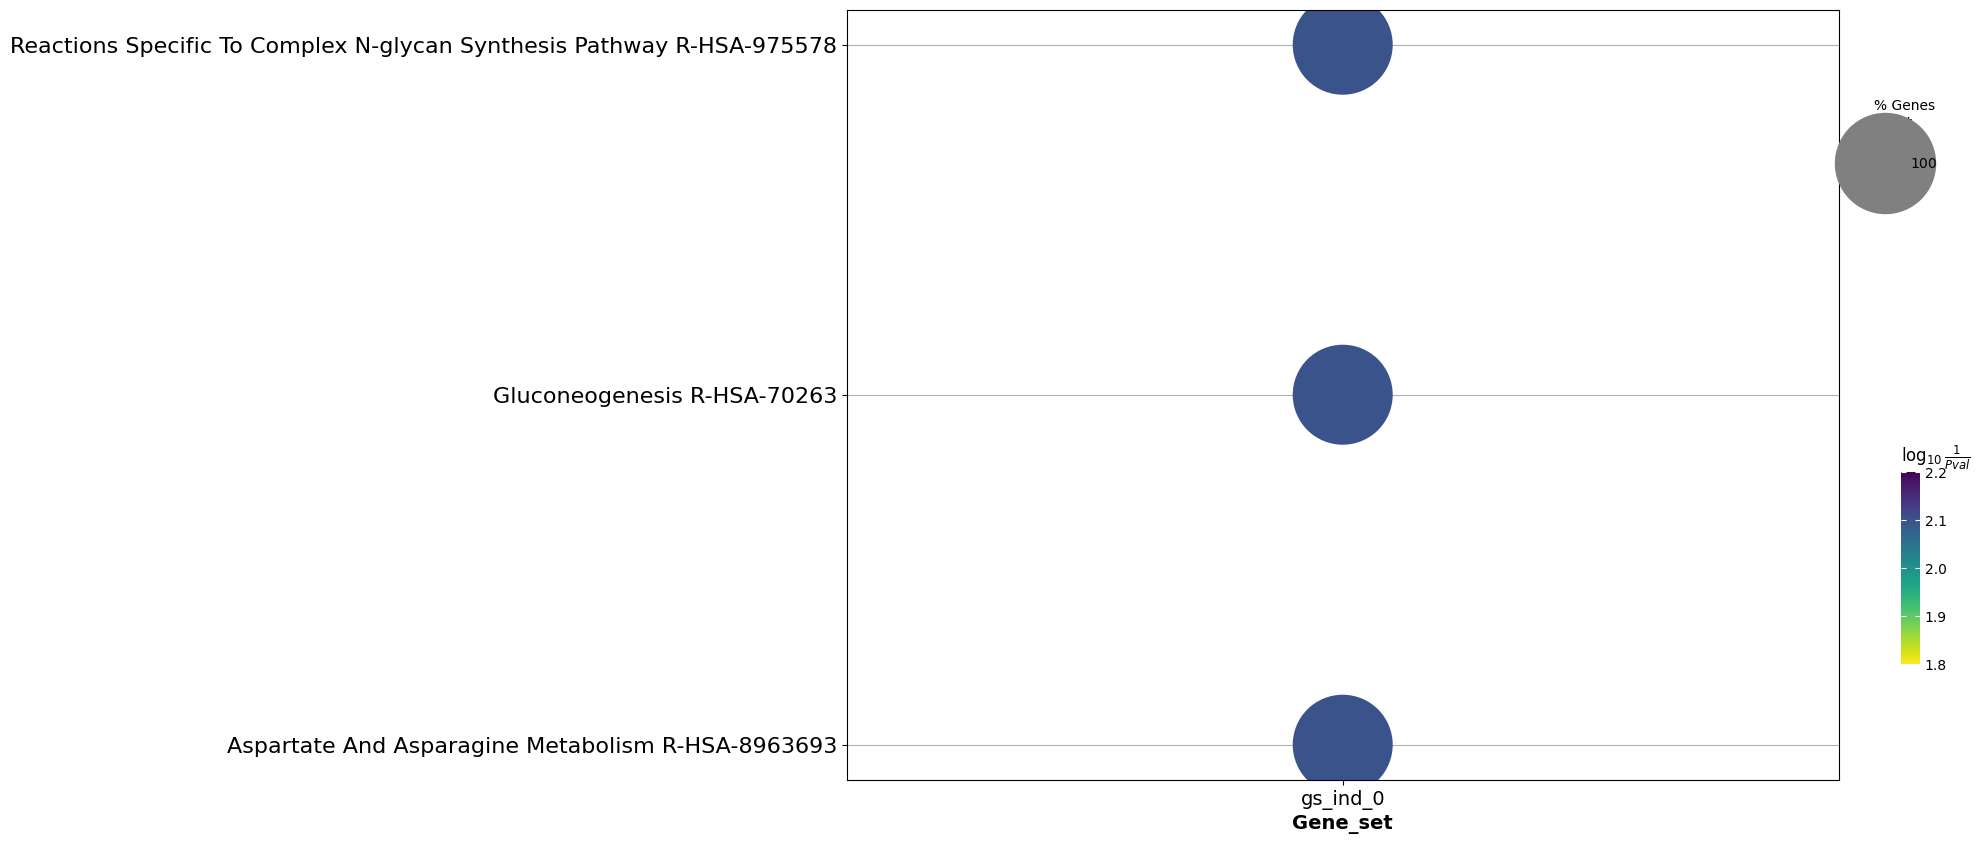

In [ ]:
passed_values = (
    passed_values
    .sort_values("P-value")
    .groupby("Gene_set")
    .head(3)
)

ax = dotplot(
    passed_values,
    column="P-value",
    x="Gene_set",
    size=12,
    top_term=5,
    figsize=(16,10),
)


In [33]:
ax = barplot(passed_values,
              column="P-value",
              group='Gene_set', 
              size=10,
              top_term=5,
              figsize=(3,5),
              color=['darkred', 'darkblue'] # set colors for group
              )

NameError: name 'barplot' is not defined

## g) Pares de genes que interaccionan sinérgicamente con el pronóstico

Modelo: **Cox-nnet** (pycox `CoxPH`), cargado desde `CoxNnet_weights.pt`. Dos métodos:

- **Método 1 — Permutación de pares** (principal): mide la sinergia real como
  `interacción = drop_conjunto − drop_i − drop_j` (análogo por permutación del H-statistic).
  Un par con `interacción > 0` aporta al pronóstico más junto que por separado.
- **Método 2 — SHAP `potential_interactions`** (contraste): para cada gen lista sus socios de interacción.

La arquitectura del modelo se **infiere automáticamente** del `.pt` (`infer_arch_from_weights`), así que no hay que ajustarla a mano aunque cambie `best_params_cn` en `nn_Cox_limma.ipynb`.

In [ ]:
"""
Apartado g) Pares de genes que interaccionan SINÉRGICAMENTE con el pronóstico.
Modelo: Cox-nnet (pycox CoxPH), cargado desde CoxNnet_weights.pt.

  MÉTODO 1 - Permutación de pares (principal): mide sinergia real como
             interaccion = drop_conjunto - drop_i - drop_j (análogo del H-statistic).
  MÉTODO 2 - SHAP potential_interactions (contraste): socios de interacción por gen.

La arquitectura se INFIERE del .pt (infer_arch_from_weights), no hay que ajustarla
a mano aunque cambie best_params_cn en nn_Cox_limma.ipynb.
Requiere en memoria: genes_expression, in_features, train_X_np, test_X_np,
test_durations, test_events y (opcional) solo_no_lineal. Usa el `tt` ya importado.
"""

import re
import numpy as np
import pandas as pd
import torch
import shap
from pycox.models.cox import CoxPH

# C-index basado en el score de riesgo (no necesita baseline hazards).
try:
    from sksurv.metrics import concordance_index_censored
    def cindex(events_bool, durations, risk):
        return concordance_index_censored(events_bool, durations, risk)[0]
except Exception:
    from lifelines.utils import concordance_index
    def cindex(events_bool, durations, risk):
        # lifelines: score alto = mayor supervivencia -> negamos el riesgo
        return concordance_index(durations, -risk, events_bool.astype(int))


# ====================== CONFIG ======================
SEED            = 42
N_REPEATS       = 12     # permutaciones por par (mas = mas estable, mas lento)
K_CANDIDATES    = 25     # nº de genes candidatos para cribar pares
COXNNET_WEIGHTS = "CoxNnet_weights.pt"
COXNNET_ARCH    = None   # None => se infiere del .pt; o dict(num_nodes=[...], batch_norm=bool, dropout=float)
# ====================================================


def _np(a):
    if torch.is_tensor(a):
        return a.detach().cpu().numpy()
    return np.asarray(a)


def infer_arch_from_weights(weights_path):
    """Deduce num_nodes y batch_norm del state_dict guardado. dropout no se puede
    inferir (no tiene parámetros) y es irrelevante en modo eval."""
    sd = torch.load(weights_path, map_location="cpu")
    if hasattr(sd, "state_dict"):
        sd = sd.state_dict()
    hidden, has_bn = {}, False
    for k, v in sd.items():
        m = re.match(r"net\.(\d+)\.linear\.weight$", k)
        if m:
            hidden[int(m.group(1))] = int(v.shape[0])
        if ".batch_norm." in k:
            has_bn = True
    return dict(num_nodes=[hidden[i] for i in sorted(hidden)], batch_norm=has_bn, dropout=0.0)


def make_predict_fn(model):
    model.net.eval()
    def predict_fn(x):
        x_tensor = torch.as_tensor(np.asarray(x, dtype=np.float32))
        with torch.no_grad():
            out = model.net(x_tensor)
        return out.cpu().numpy().reshape(-1)
    return predict_fn


def load_coxnnet(in_features, weights_path, arch=None):
    if arch is None:
        arch = infer_arch_from_weights(weights_path)
        print(f"[arquitectura inferida de {weights_path}] {arch}")
    net = tt.torchtuples.practical.MLPVanilla(
        in_features=in_features, num_nodes=arch["num_nodes"], out_features=1,
        batch_norm=arch["batch_norm"], dropout=arch.get("dropout", 0.0), output_bias=False,
    )
    model = CoxPH(net, tt.torchtuples.optim.Adam())
    try:
        model.load_model_weights(weights_path)
    except Exception as e:
        raise RuntimeError(f"No pude cargar {weights_path} con arch={arch}. Error: {e}")
    model.net.eval()
    return model


def build_candidates(gene_names, coxnnet_csv="boot_strap_df_coxnnet.csv",
                     extra_genes=None, k=25):
    """Top-k del CSV Cox-nnet (estabilidad/magnitud) unidos a solo_no_lineal."""
    name_set = set(gene_names)
    cands = []
    try:
        df = pd.read_csv(coxnnet_csv)
        sort_cols = [c for c in ["topk_freq", "mean_shap"] if c in df.columns]
        if sort_cols:
            df = df.sort_values(sort_cols, ascending=False)
        cands = [g for g in df["gene"].tolist() if g in name_set][:k]
    except Exception as e:
        print(f"[aviso] no pude leer {coxnnet_csv}: {e}")
    if extra_genes:
        for g in extra_genes:
            if g in name_set and g not in cands:
                cands.append(g)
    return cands


def permutation_pair_interactions(model, X, events_bool, durations, gene_names,
                                  candidates, n_repeats=12, seed=42):
    """interaccion = d_ij - d_i - d_j. d_ij usa la MISMA permutación en ambas
    columnas (conserva corr del par, rompe solo su vínculo con el pronóstico)."""
    predict_fn = make_predict_fn(model)
    X = np.asarray(X, dtype=np.float32)
    n = X.shape[0]
    name_to_col = {g: k for k, g in enumerate(gene_names)}
    cand = [g for g in candidates if g in name_to_col]
    col = {g: name_to_col[g] for g in cand}
    rng = np.random.default_rng(seed)

    c0 = cindex(events_bool, durations, predict_fn(X))

    d_single = {}
    for g in cand:
        drops = []
        for _ in range(n_repeats):
            Xp = X.copy()
            Xp[:, col[g]] = X[rng.permutation(n), col[g]]
            drops.append(c0 - cindex(events_bool, durations, predict_fn(Xp)))
        d_single[g] = float(np.mean(drops))

    rows = []
    for a in range(len(cand)):
        for b in range(a + 1, len(cand)):
            gi, gj = cand[a], cand[b]
            ci, cj = col[gi], col[gj]
            joint = []
            for _ in range(n_repeats):
                perm = rng.permutation(n)           
                Xp = X.copy()
                Xp[:, ci] = X[perm, ci]
                Xp[:, cj] = X[perm, cj]
                joint.append(c0 - cindex(events_bool, durations, predict_fn(Xp)))
            d_ij = float(np.mean(joint))
            inter = d_ij - d_single[gi] - d_single[gj]
            rows.append((gi, gj, d_single[gi], d_single[gj], d_ij, inter))

    out = pd.DataFrame(rows, columns=["gen_i", "gen_j", "drop_i", "drop_j",
                                      "drop_conjunto", "interaccion"])
    return c0, out.sort_values("interaccion", ascending=False).reset_index(drop=True)


def _rank_partners(sv, col, candidate_cols):
    """Socios de interacción de la columna col (solo candidatos). Robusto a versiones de SHAP."""
    try:
        order = list(shap.utils.potential_interactions(sv[:, col], sv))
    except Exception:
        try:
            order = list(shap.utils.approximate_interactions(col, sv.values, sv.data))
        except Exception:
            shap_i, feats, scores = sv.values[:, col], sv.data, []
            for k in range(feats.shape[1]):
                if k == col:
                    scores.append(-np.inf); continue
                c = np.corrcoef(shap_i, feats[:, k])[0, 1]
                scores.append(abs(c) if np.isfinite(c) else 0.0)
            order = list(np.argsort(scores)[::-1])
    return [k for k in order if k in candidate_cols and k != col]


def shap_pair_interactions(model, background_X, explain_X, gene_names, candidates,
                           n_background=50, max_evals=2001, top_partners=5):
    """Recalcula UNA explanation SHAP y lista, por gen candidato, sus socios."""
    predict_fn = make_predict_fn(model)
    bg = shap.sample(np.asarray(background_X, dtype=np.float32), n_background)
    explainer = shap.explainers.Permutation(
        predict_fn, bg, feature_names=list(gene_names), max_evals=max_evals
    )
    sv = explainer(np.asarray(explain_X, dtype=np.float32))
    name_to_col = {g: k for k, g in enumerate(gene_names)}
    cand_cols = {name_to_col[g] for g in candidates if g in name_to_col}
    rows = []
    for g in candidates:
        if g not in name_to_col:
            continue
        for rank, k_idx in enumerate(_rank_partners(sv, name_to_col[g], cand_cols)[:top_partners]):
            rows.append((g, gene_names[k_idx], rank + 1))
    return sv, pd.DataFrame(rows, columns=["gen", "socio", "rank_interaccion"])

In [ ]:
# ====================== Método 1: permutación de pares (principal) ======================
events_bool = _np(test_events).astype(bool)
durations   = _np(test_durations).astype(float)

model_cn = load_coxnnet(in_features, COXNNET_WEIGHTS, arch=COXNNET_ARCH)

candidates = build_candidates(
    genes_expression,
    coxnnet_csv="boot_strap_df_coxnnet.csv",
    extra_genes=sorted(solo_no_lineal) if "solo_no_lineal" in dir() else None,
    k=K_CANDIDATES,
)
print(f"{len(candidates)} genes candidatos: {candidates}")

c0, pares = permutation_pair_interactions(
    model_cn, test_X_np, events_bool, durations, genes_expression,
    candidates, n_repeats=N_REPEATS, seed=SEED,
)
print(f"\nC-index base del modelo: {c0:.4f}")
print("\nTop pares sinérgicos (interaccion > 0):")
print(pares.head(20).to_string(index=False))
pares.to_csv("g_pares_permutacion.csv", index=False)

In [ ]:
# ====================== Método 2: SHAP potential_interactions (contraste) ======================
sv, shap_pairs = shap_pair_interactions(
    model_cn, train_X_np, test_X_np, genes_expression, candidates,
)
print("Socios de interacción según SHAP:")
print(shap_pairs.head(20).to_string(index=False))
shap_pairs.to_csv("g_pares_shap.csv", index=False)